# Diagnóstico y mejora del modelo delay_30m — Distribution shift feb 2026

El modelo LightGBM entrenado con el histórico completo (ene–dic 2025 + ene 2026) obtenía un **MAE≈134.28s** ,pero un **MAE≈177s** en test (feb - mar 2026). Este notebook investiga por qué se produce ese salto y evalúa estrategias para reducirlo.



**Estructura:**
1. Carga de datos
2. Análisis del distribution shift (feb y mar por separado)
3. Análisis de alertas MTA — se descubre que marzo tiene el pipeline roto y se excluye del test principal
4. Impacto de la nevada (23-24 feb)
5. MAE real del modelo — versión completa (ene-dic 2025 + ene 2026) · test: feb 2026
6. Solución: ventana deslizante + pesos exponenciales (jul-dic 2025 + ene 2026) · test: feb 2026
7. Importancia de features vs drift
8. Evaluación en marzo 2026 — cuantificación del impacto del pipeline roto
9. Conclusiones

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, r2_score

from src.common.minio_client import download_df_parquet

ACCESS_KEY = os.environ['MINIO_ACCESS_KEY']
SECRET_KEY = os.environ['MINIO_SECRET_KEY']

DATA_TEMPLATE = 'grupo5/final/year={year}/month={month:02d}/dataset_final.parquet'
TARGET        = 'target_delay_30m'
FILTER_COL    = 'scheduled_time_to_end'
FILTER_VAL    = 1800

CAT_FEATURES  = ['route_id', 'direction', 'category', 'tipo_referente']
STOP_ID_COL   = 'stop_id'



## 1. Carga de datos

In [2]:
def load_months(year, months, label):
    dfs = []
    for month in months:
        path = DATA_TEMPLATE.format(year=year, month=month)
        try:
            df = download_df_parquet(ACCESS_KEY, SECRET_KEY, path)
            df = df[df['is_unscheduled'] == False]
            df = df.dropna(subset=[TARGET])
            df = df[df[FILTER_COL] >= FILTER_VAL]
            df['_periodo'] = label
            print(f'{year}-{month:02d}: {len(df):,} filas')
            dfs.append(df)
        except Exception as e:
            print(f' {year}-{month:02d}: {e}')
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

print('Cargando validación (oct-dic 2025)...')
df_val = load_months(2025, range(10, 13), 'val (oct-dic 2025)')

print('\nCargando ene 2026...')
df_ene = load_months(2026, range(1, 2), 'ene 2026')

print('\nCargando feb 2026...')
df_test = load_months(2026, range(2, 3), 'feb 2026')

print('\nCargando mar 2026...')
df_mar = load_months(2026, range(3, 4), 'mar 2026')

print(f'\nResumen:')
print(f'  val (oct-dic 2025): {len(df_val):,} filas')
print(f'  ene 2026:           {len(df_ene):,} filas')
print(f'  feb 2026:           {len(df_test):,} filas')
print(f'  mar 2026:           {len(df_mar):,} filas')

Cargando validación (oct-dic 2025)...
2025-10: 1,500,119 filas
2025-11: 1,424,947 filas
2025-12: 1,545,659 filas

Cargando ene 2026...
2026-01: 1,417,549 filas

Cargando feb 2026...
2026-02: 1,249,691 filas

Cargando mar 2026...
2026-03: 1,447,777 filas

Resumen:
  val (oct-dic 2025): 4,470,725 filas
  ene 2026:           1,417,549 filas
  feb 2026:           1,249,691 filas
  mar 2026:           1,447,777 filas


## 2. Análisis del distribution shift

Se analiza febrero y marzo por separado para ver si el *drift* continuó entre ambos meses.

El *drift*  ocurre cuando la distribución de los datos cambia con el tiempo
de forma que el modelo deja de ser válido. Un modelo se entrena con datos históricos y aprende
qué valores de las features son "normales" y qué retraso futuro suele asociarse a cada situación.
Si esa realidad cambia, por ejemplo, porque el nivel general de retrasos del metro sube de forma
sostenida — el modelo sigue usando la lógica aprendida en el pasado y produce predicciones
sistemáticamente incorrectas, aunque no haya ningún fallo en el código ni en los datos de entrada.


> Nota: en esta sección se analiza el retraso absoluto medio (`mean(|target|)`),
> que mide la magnitud típica de los retrasos en cada periodo. **No es el MAE del modelo** —
> el MAE real (error de predicción) se calcula en la Sección 5.

In [3]:
# 2.1 Estadísticas del target por periodo
print('Estadísticas del target (target_delay_30m):')
stats = pd.DataFrame({
    'val (oct-dic 2025)': df_val[TARGET].describe(),
    'ene 2026':           df_ene[TARGET].describe(),
    'feb 2026':           df_test[TARGET].describe(),
    'mar 2026':           df_mar[TARGET].describe(),
})
print(stats.round(2).to_string())

print('\nRetraso absoluto medio por periodo (≠ MAE del modelo):')
for label, df in [('val (oct-dic 2025)', df_val), ('ene 2026', df_ene),
                  ('feb 2026', df_test), ('mar 2026', df_mar)]:
    ram = df[TARGET].abs().mean()
    print(f'  {label}: {ram:.1f}s')

Estadísticas del target (target_delay_30m):
       val (oct-dic 2025)    ene 2026    feb 2026    mar 2026
count          4470725.00  1417549.00  1249691.00  1447777.00
mean               112.33      109.38      130.73      120.07
std                353.52      386.59      402.32      380.80
min              -7680.00    -3780.00    -7590.00    -3930.00
25%                -68.00      -77.00      -58.00      -65.00
50%                 55.00       48.00       65.00       57.00
75%                227.00      222.00      246.00      232.00
max               8986.00     8997.00     8806.00     8845.00

Retraso absoluto medio por periodo (≠ MAE del modelo):
  val (oct-dic 2025): 220.3s
  ene 2026: 228.0s
  feb 2026: 236.1s
  mar 2026: 227.5s


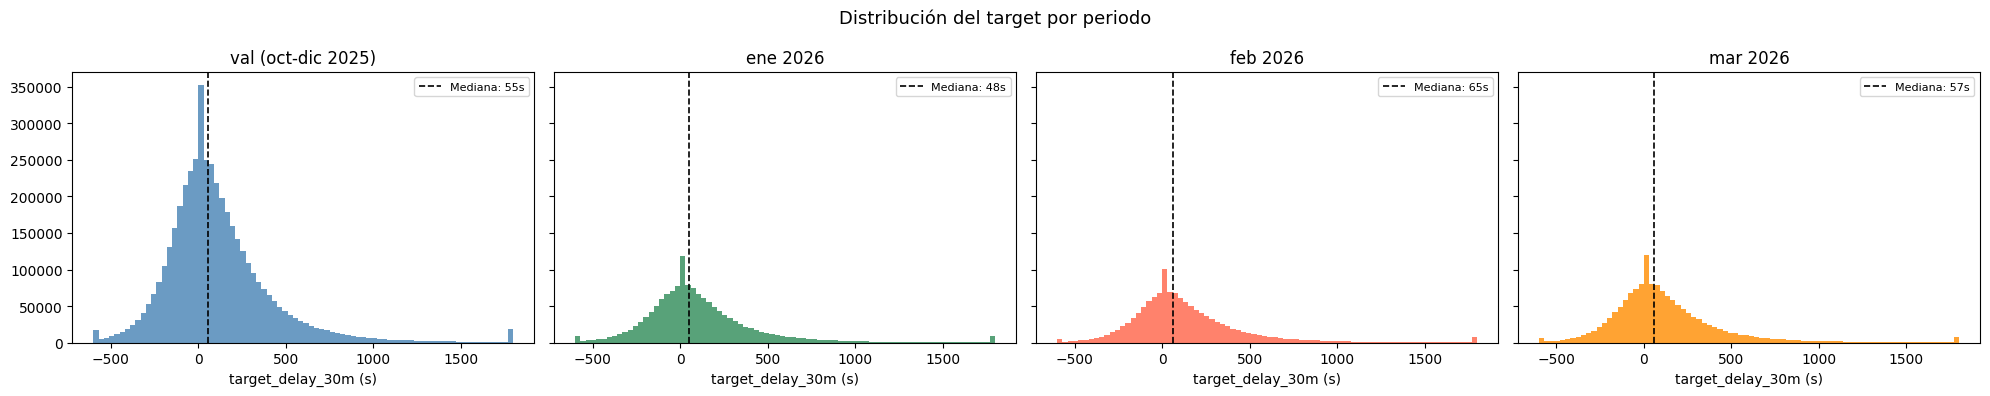

In [4]:
# 2.2 Distribución del target por periodo (feb y mar por separado)
datasets = [
    ('val (oct-dic 2025)', df_val,  'steelblue'),
    ('ene 2026',           df_ene,  'seagreen'),
    ('feb 2026',           df_test, 'tomato'),
    ('mar 2026',           df_mar,  'darkorange'),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)
for ax, (label, df, color) in zip(axes, datasets):
    data = df[TARGET].clip(-600, 1800)
    ax.hist(data, bins=80, color=color, alpha=0.8, edgecolor='none')
    ax.axvline(data.median(), color='black', linewidth=1.2, linestyle='--',
               label=f'Mediana: {data.median():.0f}s')
    ax.set_title(label)
    ax.set_xlabel('target_delay_30m (s)')
    ax.legend(fontsize=8)
plt.suptitle('Distribución del target por periodo', fontsize=13)
plt.tight_layout()
plt.show()

In [5]:
# 2.3 Empeoramiento por línea: retraso absoluto medio — feb y mar por separado
# Nota: se compara la magnitud media de retrasos, no el error del modelo
ram_val  = df_val.groupby('route_id')[TARGET].apply(lambda x: x.abs().mean()).rename('ram_validation')
ram_feb  = df_test.groupby('route_id')[TARGET].apply(lambda x: x.abs().mean()).rename('ram_feb')
ram_mar  = df_mar.groupby('route_id')[TARGET].apply(lambda x: x.abs().mean()).rename('ram_mar')

comp = pd.concat([ram_val, ram_feb, ram_mar], axis=1).dropna()
comp['delta_feb'] = comp['ram_feb'] - comp['ram_validation']
comp['delta_mar'] = comp['ram_mar'] - comp['ram_validation']
comp = comp.sort_values('delta_feb', ascending=False)

print('Cambio en retraso absoluto medio por línea (val oct-dic 2025 → feb/mar 2026):')
print(comp.round(1).to_string())

Cambio en retraso absoluto medio por línea (val oct-dic 2025 → feb/mar 2026):
          ram_validation     ram_feb     ram_mar   delta_feb   delta_mar
route_id                                                                
5             117.199997  489.700012  276.299988  372.500000  159.000000
Z             187.199997  247.699997  268.500000   60.599998   81.300003
FX            207.699997  266.399994  338.299988   58.700001  130.699997
J             185.600006  233.399994  228.699997   47.799999   43.200001
M             179.100006  210.100006  187.699997   31.000000    8.600000
B             242.800003  271.399994  239.699997   28.600000   -3.100000
A             252.500000  280.100006  266.100006   27.600000   13.600000
G             137.100006  163.899994  149.500000   26.799999   12.400000
1             130.300003  154.600006    0.000000   24.299999 -130.300003
W             202.199997  226.500000  206.699997   24.299999    4.500000
D             150.399994  167.500000  151.8000

In [6]:
# 2.4 Shift en las features de retraso más importantes — feb y mar por separado
FEATS_SHIFT = ['delay_seconds', 'lagged_delay_1', 'route_rolling_delay']

print('Shift en features clave (referencia: val oct-dic 2025):')
print(f'{"Feature":<25} {"Media val":>12} {"Media feb":>12} {"Δ feb %":>8} {"Media mar":>12} {"Δ mar %":>8}')
print('-' * 80)
for feat in FEATS_SHIFT:
    if feat not in df_val.columns:
        continue
    m_val = df_val[feat].mean()
    m_feb = df_test[feat].mean() if feat in df_test.columns else float('nan')
    m_mar = df_mar[feat].mean()  if feat in df_mar.columns  else float('nan')
    d_feb = (m_feb - m_val) / abs(m_val) * 100
    d_mar = (m_mar - m_val) / abs(m_val) * 100
    print(f'{feat:<25} {m_val:>12.1f} {m_feb:>12.1f} {d_feb:>+8.1f}% {m_mar:>12.1f} {d_mar:>+8.1f}%')

Shift en features clave (referencia: val oct-dic 2025):
Feature                      Media val    Media feb  Δ feb %    Media mar  Δ mar %
--------------------------------------------------------------------------------
delay_seconds                     90.1        103.9    +15.3%         91.8     +1.9%
lagged_delay_1                    88.4        101.9    +15.2%         89.6     +1.3%
route_rolling_delay              109.8        126.8    +15.5%        114.6     +4.3%


## 3. Análisis de alertas MTA

Se verifica el estado del pipeline de alertas en todos los periodos cargados,
incluyendo marzo 2026. Al final de esta sección se toma la decisión de excluir
marzo del test principal.

In [7]:
# 3.1 % de nulos por columna de alerta en todos los periodos
ALERT_COLS = ['alert_in_next_15m', 'alert_in_next_30m',
              'seconds_to_next_alert', 'seconds_since_last_alert']
alert_cols_ok = [c for c in ALERT_COLS if c in df_val.columns]

print('=== % de nulos por columna de alerta ===')
periodos = [
    ('val (oct-dic 2025)', df_val),
    ('ene 2026',           df_ene),
    ('feb 2026',           df_test),
    ('mar 2026',           df_mar),
]
for col in alert_cols_ok:
    print(f'\n{col}:')
    for label, df in periodos:
        if df.empty or col not in df.columns:
            continue
        pct = df[col].isnull().mean() * 100
        print(f'  {label}: {pct:.1f}% nulos')

=== % de nulos por columna de alerta ===

alert_in_next_15m:
  val (oct-dic 2025): 0.0% nulos
  ene 2026: 0.0% nulos
  feb 2026: 0.0% nulos
  mar 2026: 0.0% nulos

alert_in_next_30m:
  val (oct-dic 2025): 0.0% nulos
  ene 2026: 0.0% nulos
  feb 2026: 0.0% nulos
  mar 2026: 0.0% nulos

seconds_to_next_alert:
  val (oct-dic 2025): 3.9% nulos
  ene 2026: 2.4% nulos
  feb 2026: 2.6% nulos
  mar 2026: 100.0% nulos

seconds_since_last_alert:
  val (oct-dic 2025): 0.2% nulos
  ene 2026: 0.1% nulos
  feb 2026: 0.2% nulos
  mar 2026: 0.8% nulos


>Aquí se observa, que el pipelines de alertas para el mes de marzo, no está funcionando correctamente. Cuando se subieron los datos a Minio la API de alertas, no había subido aun el mes de marzo

In [8]:
# 3.2 Nulos de seconds_to_next_alert mes a mes (confirma rotura en marzo 2026)
print('=== seconds_to_next_alert: % nulos por mes ===')
todos = pd.concat([df_val, df_ene, df_test, df_mar], ignore_index=True)
todos['_year']  = pd.to_datetime(todos['date']).dt.year
todos['_month'] = pd.to_datetime(todos['date']).dt.month

for (year, month), grp in todos.groupby(['_year', '_month']):
    pct = grp['seconds_to_next_alert'].isnull().mean() * 100
    print(f'  {year}-{month:02d}: {pct:.1f}% nulos  ({len(grp):,} filas)')

=== seconds_to_next_alert: % nulos por mes ===
  2025-10: 3.6% nulos  (1,500,119 filas)
  2025-11: 3.2% nulos  (1,424,947 filas)
  2025-12: 4.8% nulos  (1,545,659 filas)
  2026-01: 2.4% nulos  (1,417,549 filas)
  2026-02: 2.6% nulos  (1,249,691 filas)
  2026-03: 100.0% nulos  (1,447,777 filas)


### Decisión: marzo excluido del test principal

`seconds_to_next_alert` está al **100% nulo en marzo 2026** por un fallo del pipeline
de `data.ny.gov` — las alertas MTA de ese mes no estaban subidas a la API cuando se
realizó este análisis.

Dado que el modelo fue entrenado con esa feature activa, evaluarlo sobre marzo con
alertas nulas mezclaría dos fuentes de error distintas (drift + datos rotos) y haría
imposible aislar cada causa.

**A partir de aquí, el test principal es febrero 2026.**  
Marzo se retoma en la sección 8 exclusivamente para cuantificar el impacto del pipeline roto.

## 4. Impacto de la nevada (23-24 feb 2026)

Se analizó si los días de nevada inflaban artificialmente el retraso absoluto medio del periodo de test.

In [9]:
NEVADA_DATES = ['2026-02-23', '2026-02-24']
df_test['_date'] = pd.to_datetime(df_test['date'])

df_nevada    = df_test[df_test['_date'].dt.strftime('%Y-%m-%d').isin(NEVADA_DATES)]
df_sin_nieve = df_test[~df_test['_date'].dt.strftime('%Y-%m-%d').isin(NEVADA_DATES)]

ram_global    = df_test[TARGET].abs().mean()
ram_nevada    = df_nevada[TARGET].abs().mean()
ram_sin_nieve = df_sin_nieve[TARGET].abs().mean()
ram_val       = df_val[TARGET].abs().mean()

print(f'Filas en días de nevada: {len(df_nevada):,} ({len(df_nevada)/len(df_test)*100:.1f}% del test)\n')
print('Retraso absoluto medio (≠ MAE del modelo):')
print(f'  Referencia val (oct-dic 2025):  {ram_val:.1f}s')
print(f'  Test global (feb 2026):         {ram_global:.1f}s')
print(f'  Solo días de nevada:            {ram_nevada:.1f}s')
print(f'  Sin días de nevada:             {ram_sin_nieve:.1f}s')
print(f'\n→ La nevada explica solo {ram_global - ram_sin_nieve:.1f}s del incremento total de {ram_global - ram_val:.1f}s')
print('→ El grueso del empeoramiento es distribution shift, no la nevada.')

Filas en días de nevada: 51,628 (4.1% del test)

Retraso absoluto medio (≠ MAE del modelo):
  Referencia val (oct-dic 2025):  220.3s
  Test global (feb 2026):         236.1s
  Solo días de nevada:            449.1s
  Sin días de nevada:             226.9s

→ La nevada explica solo 9.2s del incremento total de 15.8s
→ El grueso del empeoramiento es distribution shift, no la nevada.


## 5. MAE real del modelo — versión completa

A partir de aquí se calculan predicciones reales del modelo para obtener el **MAE verdadero**  
(error de predicción), distinguiéndolo del retraso absoluto medio analizado anteriormente.

In [10]:
EXCLUDE_M = {
    'date', 'match_key', 'stop_id', 'merge_time', 'timestamp_start',
    'service_date', 'trip_uid', 'is_unscheduled',
    'target_delay_10m', 'target_delay_20m', 'target_delay_30m',
    'target_delay_45m', 'target_delay_60m', 'target_delay_end',
    'delta_delay_10m', 'delta_delay_20m', 'delta_delay_30m',
    'delta_delay_45m', 'delta_delay_60m', 'delta_delay_end',
    'alert_in_next_15m', 'alert_in_next_30m', 'seconds_to_next_alert',
    'delay_minutes', 'scheduled_time', 'actual_time',
    '_periodo', '_date', '_route_id',
}

LGBM_PARAMS = {
    'objective': 'regression_l1', 'metric': 'mae',
    'learning_rate': 0.05, 'num_leaves': 511, 'max_depth': 16,
    'min_child_samples': 100, 'min_split_gain': 0.37042771510661165,
    'feature_fraction': 0.7426288737567357, 'bagging_fraction': 0.8165370010747616,
    'bagging_freq': 5, 'reg_alpha': 1.5346393797283635,
    'reg_lambda': 1.2926631392622208, 'n_jobs': -1, 'verbose': -1, 'seed': 42,
}
NUM_BOOST_ROUND = 4260

def encode_cat(tr, te):
    for col in CAT_FEATURES:
        if col not in tr.columns: continue
        vocab = {v: i for i, v in enumerate(tr[col].astype(str).unique())}
        tr[col] = tr[col].astype(str).map(vocab).astype(int)
        te[col] = te[col].astype(str).map(vocab).fillna(-1).astype(int)
    return tr, te

def add_te(tr, te, col, target):
    means = tr.groupby(col)[target].mean()
    tr[f'{col}_target_enc'] = tr[col].map(means)
    te[f'{col}_target_enc'] = te[col].map(means).fillna(tr[target].mean())
    return tr, te

def add_feats(df):
    if 'lagged_delay_1' in df.columns and 'delay_seconds' in df.columns:
        df['delay_velocity'] = df['delay_seconds'] - df['lagged_delay_1']
    if 'lagged_delay_1' in df.columns and 'lagged_delay_2' in df.columns:
        df['delay_acceleration'] = (
            (df['delay_seconds'] - df['lagged_delay_1'])
            - (df['lagged_delay_1'] - df['lagged_delay_2'])
        )
    if 'delay_seconds' in df.columns and 'stops_to_end' in df.columns:
        df['delay_x_stops_remaining'] = df['delay_seconds'] * df['stops_to_end']
    if 'delay_seconds' in df.columns and 'scheduled_time_to_end' in df.columns:
        df['delay_ratio'] = df['delay_seconds'] / (df['scheduled_time_to_end'] + 1)
    return df

def get_feats(df):
    return [c for c in df.columns if c not in EXCLUDE_M and c != TARGET]

def load_train(year, months):
    dfs = []
    for month in months:
        path = DATA_TEMPLATE.format(year=year, month=month)
        try:
            df = download_df_parquet(ACCESS_KEY, SECRET_KEY, path)
            df = df[df['is_unscheduled'] == False]
            df = df.dropna(subset=[TARGET])
            df = df[df[FILTER_COL] >= FILTER_VAL]
            for col in CAT_FEATURES:
                if col in df.columns:
                    df[col] = df[col].astype('category')
            print(f'  {year}-{month:02d}: {len(df):,} filas')
            dfs.append(df)
        except Exception as e:
            print(f'  {year}-{month:02d}: error ({e})')
    return pd.concat(dfs, ignore_index=True)


In [11]:
# Cargar train: ene-dic 2025 + ene 2026 (versión completa)
print('Cargando train ene-dic 2025...')
dft25_full = load_train(2025, range(1, 13))
print('Cargando train ene 2026...')
dft26      = load_train(2026, range(1, 2))
df_tr_full = pd.concat([dft25_full, dft26], ignore_index=True)
print(f'Total train completo: {len(df_tr_full):,} filas')

Cargando train ene-dic 2025...
  2025-01: 1,299,597 filas
  2025-02: 1,264,121 filas
  2025-03: 1,430,801 filas
  2025-04: 1,320,703 filas
  2025-05: 1,232,441 filas
  2025-06: 1,287,542 filas
  2025-07: 1,320,327 filas
  2025-08: 1,386,955 filas
  2025-09: 1,410,181 filas
  2025-10: 1,500,119 filas
  2025-11: 1,424,947 filas
  2025-12: 1,545,659 filas
Cargando train ene 2026...
  2026-01: 1,417,549 filas
Total train completo: 17,840,942 filas


In [ ]:

df_tr_f = df_tr_full
df_te_f = df_test
df_te_f['_route_id'] = df_te_f['route_id'].astype(str)

df_tr_f, df_te_f = encode_cat(df_tr_f, df_te_f)
df_tr_f, df_te_f = add_te(df_tr_f, df_te_f, STOP_ID_COL, TARGET)
df_tr_f = add_feats(df_tr_f)
df_te_f = add_feats(df_te_f)

feats_f = get_feats(df_tr_f)
print(f'Entrenando modelo completo ({NUM_BOOST_ROUND} iters, {len(feats_f)} features)...')
model_full = lgb.train(
    LGBM_PARAMS,
    lgb.Dataset(df_tr_f[feats_f], label=df_tr_f[TARGET]),
    num_boost_round=NUM_BOOST_ROUND,
    callbacks=[lgb.log_evaluation(1000)],
)

df_tr_f['_pred'] = model_full.predict(df_tr_f[feats_f])
df_te_f['_pred'] = model_full.predict(df_te_f[feats_f])

mae_full_train = mean_absolute_error(df_tr_f[TARGET], df_tr_f['_pred'])
r2_full_train  = r2_score(df_tr_f[TARGET], df_tr_f['_pred'])
mae_full       = mean_absolute_error(df_te_f[TARGET], df_te_f['_pred'])
r2_full        = r2_score(df_te_f[TARGET], df_te_f['_pred'])

print(f'\nMétricas modelo completo:')
print(f'  Train (ene-dic 2025 + ene 2026): MAE={mae_full_train:.2f}s  |  R²={r2_full_train:.4f}')
print(f'  Test  (feb 2026):                MAE={mae_full:.2f}s  |  R²={r2_full:.4f}')


Entrenando modelo completo (4260 iters, 31 features)...

Métricas modelo completo:
  Train (ene-dic 2025 + ene 2026): MAE=117.06s  |  R²=0.6334
  Test  (feb 2026):                MAE=163.12s  |  R²=0.5151


In [13]:
# Sobreestimación sistemática por línea
print('=== MAE y sesgo por línea — modelo completo ===\n')
by_line_full = df_te_f.groupby('_route_id').apply(lambda g: pd.Series({
    'n_filas':  len(g),
    'mae_s':    mean_absolute_error(g[TARGET], g['_pred']),
    'r2':       r2_score(g[TARGET], g['_pred']),
    'sesgo_s':  (g['_pred'] - g[TARGET]).mean(),
})).sort_values('mae_s', ascending=False)
print(by_line_full.round(1).to_string())

# Conservar solo columnas necesarias para comparaciones posteriores.
df_te_f = df_te_f[['_route_id', TARGET, '_pred']]

=== MAE y sesgo por línea — modelo completo ===

            n_filas  mae_s   r2  sesgo_s
_route_id                               
6              23.0  336.2  0.3    132.1
B           63130.0  206.9  0.4     70.3
SI           5715.0  204.2  0.2    -24.1
W           22618.0  202.5  0.4     61.2
E           72935.0  187.3  0.5     45.7
4              73.0  178.1  0.0     70.9
N          102276.0  174.0  0.5     41.7
R          153543.0  171.3  0.4     49.2
Z            1495.0  170.3  0.2     19.3
F          190582.0  169.9  0.5     24.0
M           61010.0  166.6  0.5     26.8
A          170025.0  161.1  0.6    -15.9
Q           97139.0  160.7  0.4     23.8
FX           1811.0  160.0  0.7    -31.5
C           99704.0  146.7  0.4     35.9
J           65294.0  146.1  0.5     -5.1
5              39.0  145.2  0.2    -97.9
1              19.0  122.5 -8.0   -122.3
D          123071.0  120.7  0.6      5.1
G           19109.0  111.6  0.4    -16.0
3              41.0  111.1 -0.9    -67.6
2       

## 6. Solución: ventana deslizante (jul-dic 2025 + ene 2026) con pesos exponenciales                                                                                                  
                        
  ### Motivación                                                                                                                                                                        
                                                                                                                                                                                        
  El análisis de las secciones anteriores revela que el empeoramiento del modelo no se debe a                                                                                           
  un fallo puntual sino a **drift**: el régimen de retrasos del metro en 2026 es                                                                                                
  sistemáticamente más alto que en 2025 (+15% en `delay_seconds`, +17% en `route_rolling_delay`).                                                                                       

  El modelo entrenado con todo 2025 aprendió que valores de retraso actuales de ~100s eran
  "casos altos" y predecía futuros aún más altos — produciendo sobreestimaciones de +70s (línea B)
  y +46s (línea E).

  ### Solución: ventana deslizante + pesos exponenciales

  Se combinan dos estrategias complementarias:

  **1. Ventana deslizante (jul-dic 2025 + ene 2026, 7 meses)**
  En lugar de usar todos los datos históricos, se entrena solo con los últimos 7 meses.
  Esto acerca el train temporalmente al test y da más peso implícito al 2º semestre de 2025,
  donde los retrasos ya eran más altos.

  **2. Pesos exponenciales por mes**
  Dentro de la ventana, cada mes recibe un peso que crece exponencialmente hacia los más recientes.
  Se eligió **exponential sobre linear** porque obtiene mejor MAE test (137.06s vs 137.37s)
  y menor gap train/test (17.8s vs 19.6s) — generaliza mejor y tiene menos sobreajuste.

  **Búsqueda sistemática realizada** (`window_weight_search_30m_results.csv`, 28 combinaciones):

  | window | weight | n_months | test_mae_s | test_r2 | train_mae_s | gap |
  |---|---|---|---|---|---|---|
  | **desde_jul25** | **exponential** | **7** | **137.06** | **0.5627** | **119.21** | **17.8** |
  | desde_jul25 | linear | 7 | 137.37 | 0.5646 | 117.80 | 19.6 |
  | desde_sep25 | step | 5 | 137.40 | 0.5539 | 115.01 | 22.4 |

  → Exponential elegido por mejor MAE test y menor gap (menos overfitting). Es la estrategia
  estándar en ML de producción para mitigar concept drift sin necesitar datos del periodo de test.

In [14]:
# Cargar train: jul-dic 2025 + ene 2026 (ventana deslizante)
print('Cargando train jul-dic 2025 (sliding window)...')
dft25_sw = load_train(2025, range(7, 13))
print('Cargando train ene 2026...')
df_tr_sw = pd.concat([dft25_sw, dft26], ignore_index=True)
print(f'Total train sliding: {len(df_tr_sw):,} filas')
print(f'(vs {len(df_tr_full):,} del modelo completo — {len(df_tr_sw)/len(df_tr_full)*100:.0f}% de los datos)')

Cargando train jul-dic 2025 (sliding window)...
  2025-07: 1,320,327 filas
  2025-08: 1,386,955 filas
  2025-09: 1,410,181 filas
  2025-10: 1,500,119 filas
  2025-11: 1,424,947 filas
  2025-12: 1,545,659 filas
Cargando train ene 2026...
Total train sliding: 10,005,737 filas
(vs 17,840,942 del modelo completo — 56% de los datos)


In [15]:
df_tr_s = df_tr_sw
print('Recargando test (feb 2026)')
df_te_s = load_months(2026, range(2, 3), 'test (feb 2026)')
df_te_s['_route_id'] = df_te_s['route_id'].astype(str)
df_te_s['_date']     = pd.to_datetime(df_te_s['date'])

df_tr_s, df_te_s = encode_cat(df_tr_s, df_te_s)
df_tr_s, df_te_s = add_te(df_tr_s, df_te_s, STOP_ID_COL, TARGET)
df_tr_s = add_feats(df_tr_s)
df_te_s = add_feats(df_te_s)

feats_s = get_feats(df_tr_s)


month_sizes = (
    df_tr_s.assign(_ym=pd.to_datetime(df_tr_s['date']).dt.to_period('M'))
    .groupby('_ym').size().sort_index().tolist()
)
n = len(month_sizes)
lam = np.log(10) / max(n - 1, 1)
w = np.exp(lam * np.arange(n))
w = w / w.mean()

weights = np.concatenate([np.full(s, wi) for s, wi in zip(month_sizes, w)]).astype(np.float32)
print(f'Pesos exponenciales por mes: {dict(zip(sorted(df_tr_s.assign(_ym=pd.to_datetime(df_tr_s["date"]).dt.to_period("M"))["_ym"].unique()), w.round(2)))}')

print(f'Entrenando modelo sliding + pesos exponenciales ({NUM_BOOST_ROUND} iters, {len(feats_s)} features)...')
model_sw = lgb.train(
    LGBM_PARAMS,
    lgb.Dataset(df_tr_s[feats_s], label=df_tr_s[TARGET], weight=weights, free_raw_data=True),
    num_boost_round=NUM_BOOST_ROUND,
    callbacks=[lgb.log_evaluation(1000)],
)

df_tr_s['_pred'] = model_sw.predict(df_tr_s[feats_s])
df_te_s['_pred'] = model_sw.predict(df_te_s[feats_s])

mae_sw_train = mean_absolute_error(df_tr_s[TARGET], df_tr_s['_pred'])
r2_sw_train  = r2_score(df_tr_s[TARGET], df_tr_s['_pred'])
mae_sw       = mean_absolute_error(df_te_s[TARGET], df_te_s['_pred'])
r2_sw        = r2_score(df_te_s[TARGET], df_te_s['_pred'])

print(f'\nMétricas modelo sliding + pesos exponenciales:')
print(f'  Train (jul-dic 2025 + ene 2026): MAE={mae_sw_train:.2f}s  |  R²={r2_sw_train:.4f}')
print(f'  Test  (feb 2026):                MAE={mae_sw:.2f}s  |  R²={r2_sw:.4f}')
print(f'\nMejora vs modelo completo (test): {mae_full - mae_sw:.1f}s ({(mae_full - mae_sw)/mae_full*100:.1f}%)')
print(f'Gap train/test sliding+exponential:    {mae_sw - mae_sw_train:.1f}s  (vs {mae_full - mae_full_train:.1f}s del completo)')
print(f'\n→ Referencia búsqueda (window_weight_search): test_mae=137.37s, gap=19.6s')

Recargando test (feb 2026)
2026-02: 1,249,691 filas
Pesos exponenciales por mes: {Period('2025-07', 'M'): np.float64(0.24), Period('2025-08', 'M'): np.float64(0.35), Period('2025-09', 'M'): np.float64(0.52), Period('2025-10', 'M'): np.float64(0.76), Period('2025-11', 'M'): np.float64(1.11), Period('2025-12', 'M'): np.float64(1.63), Period('2026-01', 'M'): np.float64(2.39)}
Entrenando modelo sliding + pesos exponenciales (4260 iters, 31 features)...

Métricas modelo sliding + pesos exponenciales:
  Train (jul-dic 2025 + ene 2026): MAE=116.04s  |  R²=0.6274
  Test  (feb 2026):                MAE=136.64s  |  R²=0.5702

Mejora vs modelo completo (test): 26.5s (16.2%)
Gap train/test sliding+exponential:    20.6s  (vs 46.1s del completo)

→ Referencia búsqueda (window_weight_search): test_mae=137.37s, gap=19.6s


In [16]:
# MAE y sesgo por línea — modelo sliding
print('=== MAE y sesgo por línea — modelo sliding ===\n')
by_line_sw = df_te_s.groupby('_route_id').apply(lambda g: pd.Series({
    'n_filas':  len(g),
    'mae_s':    mean_absolute_error(g[TARGET], g['_pred']),
    'r2':       r2_score(g[TARGET], g['_pred']),
    'sesgo_s':  (g['_pred'] - g[TARGET]).mean(),
})).sort_values('mae_s', ascending=False)
print(by_line_sw.round(1).to_string())

=== MAE y sesgo por línea — modelo sliding ===

            n_filas  mae_s   r2  sesgo_s
_route_id                               
6              23.0  323.1  0.2    216.7
5              39.0  216.6 -0.6   -181.2
SI           5715.0  205.1  0.2    -28.1
4              73.0  187.9 -0.0     26.8
E           72935.0  159.3  0.6    -23.6
FX           1811.0  155.7  0.7    -39.0
W           22618.0  153.8  0.5    -18.8
B           63130.0  151.7  0.5    -19.8
F          190582.0  145.2  0.6    -14.0
A          170025.0  145.0  0.6    -37.3
N          102276.0  142.6  0.6     -2.7
M           61010.0  139.4  0.6    -18.8
Q           97139.0  135.7  0.5    -13.6
R          153543.0  133.8  0.5    -18.0
J           65294.0  128.6  0.5    -32.9
Z            1495.0  121.6  0.3    -48.5
C           99704.0  115.5  0.6    -15.3
1              19.0  114.7 -6.9   -113.2
3              41.0  114.2 -0.9    -13.5
D          123071.0  108.0  0.5    -16.8
G           19109.0  107.5  0.4    -26.3
2        

>La linea 5 y 6 estuvieron de obras durante todo el mes de febrero, en distintas paradas.

In [18]:
# Impacto de exclusiones sobre el MAE real (modelo sliding)
LINEAS_AF = ['5', '6', 'FX', 'Z', 'J']
NIEVE     = ['2026-02-23', '2026-02-24']

df_sl = df_te_s[~df_te_s['_route_id'].isin(LINEAS_AF)]
df_sn = df_te_s[~df_te_s['_date'].dt.strftime('%Y-%m-%d').isin(NIEVE)]
df_lp = df_sn[~df_sn['_route_id'].isin(LINEAS_AF)]

def mr(df): return mean_absolute_error(df[TARGET], df['_pred']), r2_score(df[TARGET], df['_pred'])

mg, rg   = mr(df_te_s)
msl, rsl = mr(df_sl)
msn, rsn = mr(df_sn)
mlp, rlp = mr(df_lp)

print('=== MAE real modelo sliding: impacto de exclusiones ===\n')
print(f'Global (100%):                    MAE={mg:.1f}s   R²={rg:.4f}')
print(f'Sin líneas anómalas ({len(df_sl)/len(df_te_s)*100:.1f}%):    MAE={msl:.1f}s   R²={rsl:.4f}')
print(f'Sin nevada ({len(df_sn)/len(df_te_s)*100:.1f}%):              MAE={msn:.1f}s   R²={rsn:.4f}')
print(f'Sin líneas + sin nevada ({len(df_lp)/len(df_te_s)*100:.1f}%): MAE={mlp:.1f}s   R²={rlp:.4f}')
print(f'\nReferencia val oct-dic 2025:      MAE≈130s')

=== MAE real modelo sliding: impacto de exclusiones ===

Global (100%):                    MAE=136.6s   R²=0.5702
Sin líneas anómalas (94.5%):    MAE=137.1s   R²=0.5715
Sin nevada (95.9%):              MAE=132.3s   R²=0.5685
Sin líneas + sin nevada (90.6%): MAE=133.0s   R²=0.5710

Referencia val oct-dic 2025:      MAE≈130s


## 9. Conclusiones

| Configuración | Test | MAE test |
|---|---|---|
| Año completo (ene–dic 2025 + ene 2026) | enero 2026 | 133s |
| Año completo (ene–dic 2025 + ene 2026) | feb + mar 2026 | 177s |
| Ventana deslizante jul–dic 2025 + ene 2026, pesos exponenciales | febrero 2026 | 136.6s |

### Por qué fallaba en febrero

El problema es **concept drift**: en febrero 2026 el nivel de retrasos del metro subió un +15% respecto a 2025 (`delay_seconds`, `lagged_delay_1` y `route_rolling_delay` se desplazaron todos en la misma dirección). El modelo entrenado con todo 2025 había aprendido que ~100s de retraso actual era un caso "alto" y predecía futuros más elevados. En febrero ese nivel ya era el nuevo normal, produciendo sobreestimaciones sistemáticas de hasta +70s en líneas como B o E. La ventana deslizante corrige esto al entrenar solo con los meses más cercanos al test, reduciendo el MAE de 163s a 136.6s.

### Por qué fallaba en marzo

En marzo se acumulan dos problemas simultáneos. Por un lado, el pipeline de alertas MTA estaba roto: `seconds_to_next_alert` aparece al 100% nulo ese mes, por lo que el modelo recibe NaN donde en train tenía señal real, introduciendo un sesgo global de −36.6s. Por otro lado, el drift residual continúa aunque moderado (+1–4% frente al +15% de febrero).